# Step 5: Connecting Python to SQL

# Step 5.1: Install and Import Libraries

In [1]:
!pip install pandas sqlalchemy pymysql

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as scipy_stats
import statsmodels.api as sm
from scipy.stats import ttest_ind, f_oneway, chi2_contingency
import pymysql
from sqlalchemy import create_engine, text
from sklearn.preprocessing import MinMaxScaler, StandardScaler
print("Libraries imported successfully")

Libraries imported successfully


# Step 5.2: Create a Connection String

In [3]:
# Database Configuration Paramerters
from sqlalchemy import create_engine
username = "root"            
password = "1234"
host = "localhost"
port = "3306"
database = "UPI_Transaction_Analytics"
# Create SQLAlchemy Engine
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}/{database}")
print("Connection engine created successfully")       

Connection engine created successfully


In [4]:
# Test the connection
try:
    connection = engine.connect()
    connection.execute(text("Select 1"))
    connection.close()
    print("MySQL connection successful")
except Exception as e:
    print("Connection Failed")
    print(e)

MySQL connection successful


# Step 5.3: Run a Query Using pandas.read_sql_query

In [5]:
query = "Select * from Customer_Master limit 10"
sample_data = pd.read_sql_query(query, engine)
sample_data

,Customer_ID,Full_Name,Mobile_Number,Age,Gender,Region,Date_Joined,Is_Business_User,Risk_Score,Validation_Status
0,CUST100000,Ryan Gallagher,7631706690,26,Female,North,2024-01-28,FALSE,0.39,Valid
1,CUST100001,Robert Garza,806360837,49,Female,West,2025-04-16,FALSE,0.13,Review Required
2,CUST100002,Haley Rhodes,8124158683,68,Male,West,2022-02-10,TRUE,0.14,Valid
3,CUST100003,Sonya Mathis,3662585178,42,Male,North,2021-02-18,FALSE,0.07,Valid
4,CUST100004,Ryan Wood,9996228303,35,Female,South,2023-04-17,FALSE,0.30,Valid
5,CUST100005,Crystal Palmer,9068288360,24,Female,North,2022-12-31,TRUE,0.00,Valid
6,CUST100006,Julian Everett,5088995790,59,Female,West,2024-08-13,FALSE,0.41,Valid
7,CUST100007,Krista White,1107043419,45,Female,Central,2021-07-08,FALSE,0.11,Valid
8,CUST100008,Christopher Scott,5771046563,46,Female,Central,2021-11-20,FALSE,0.24,Valid
9,CUST100009,Nicholas Davila,6202786838,32,Female,West,2022-11-06,FALSE,0.17,Valid


# Step 5.4: Load all tables into dataframes

In [6]:
df_customer = pd.read_sql_query("Select * from Customer_Master", engine)
print("Customer_Master loaded:", len(df_customer),"rows")

Customer_Master loaded: 10000 rows


In [7]:
df_device = pd.read_sql_query("Select * from Device_Info", engine)
print("Device_Info loaded:", len(df_device),"rows")

Device_Info loaded: 12000 rows


In [8]:
df_account = pd.read_sql_query("Select * from UPI_Account_Details", engine)
print("UPI_Account_Details loaded:", len(df_account),"rows")

UPI_Account_Details loaded: 12000 rows


In [9]:
df_merchant = pd.read_sql_query("Select * from Merchant_Info", engine)
print("Merchant_Info loaded:", len(df_merchant),"rows")

Merchant_Info loaded: 500 rows


In [10]:
df_transaction = pd.read_sql_query("Select * from UPI_Transaction_History", engine)
print("UPI_Transaction_History loaded:", len(df_transaction),"rows")

UPI_Transaction_History loaded: 100000 rows


In [11]:
df_feedback = pd.read_sql_query("Select * from Customer_Feedback_Surveys", engine)
print("Customer_Feedback_Surveys loaded:", len(df_feedback),"rows")

Customer_Feedback_Surveys loaded: 4000 rows


In [12]:
df_fraud = pd.read_sql_query("Select * from Fraud_Alert_History", engine)
print("Fraud_Alert_History loaded:", len(df_fraud),"rows")

Fraud_Alert_History loaded: 2000 rows


# Step 5.5: Validate Schema and Record counts

In [13]:
table_list = [("Customer_Master", df_customer),
             ("Device_Info", df_device),
             ("UPI_Account_Details",df_account),
             ("Merchant_Info", df_merchant),
             ("UPI_Transaction_History", df_transaction),
             ("Customer_Feedback_Surveys",df_feedback),
             ("Fraud_Alert_History", df_fraud)]
# Collect the info for each table into a simple list
summary_rows =[]
for table_name,df in table_list:
    summary_rows.append({
                        "Table Name": table_name,
                        "Rows": df.shape[0],
                        "Columns": df.shape[1],
                        "Missing Values": df.isnull().sum().sum()})
# Convert that list into a table 
validation_table = pd.DataFrame(summary_rows)
validation_table

,Table Name,Rows,Columns,Missing Values
0,Customer_Master,10000,10,0
1,Device_Info,12000,7,0
2,UPI_Account_Details,12000,7,0
3,Merchant_Info,500,7,0
4,UPI_Transaction_History,100000,16,0
5,Customer_Feedback_Surveys,4000,8,0
6,Fraud_Alert_History,2000,8,248


In [14]:
for table_name, df in table_list:
    print("==========================")
    print("Schema:", table_name)
    print("==========================")
    df.info()
    print()

Schema: Customer_Master
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        10000 non-null  object 
 1   Full_Name          10000 non-null  object 
 2   Mobile_Number      10000 non-null  object 
 3   Age                10000 non-null  int64  
 4   Gender             10000 non-null  object 
 5   Region             10000 non-null  object 
 6   Date_Joined        10000 non-null  object 
 7   Is_Business_User   10000 non-null  object 
 8   Risk_Score         10000 non-null  float64
 9   Validation_Status  10000 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 781.4+ KB

Schema: Device_Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  ----

# Step 6: Data Cleaning, Transformation and Enhanced EDA

# Step 6.1: Check and handle missing values

In [15]:
# Check how many missing values each table has
for table_name, df in table_list:
    missing_count = df.isnull().sum().sum()
    if missing_count > 0:
        print(f"{table_name} has {missing_count} missing values")
        missing_columns = df.isnull().sum()
        print(missing_columns[missing_columns > 0])
    else:
        print(f"{table_name} has no missing values")
    print()

Customer_Master has no missing values

Device_Info has no missing values

UPI_Account_Details has no missing values

Merchant_Info has no missing values

UPI_Transaction_History has no missing values

Customer_Feedback_Surveys has no missing values

Fraud_Alert_History has 248 missing values
resolution_time    248
dtype: int64



In [16]:
# Treat missing values
# For merchant_id: a missing value means it was a person to person transaction, not a merchant payment
df_transaction["Merchant_ID"] = df_transaction["Merchant_ID"].fillna("P2P_No_Merchant")
# For failure_reason: a missing value means the transaction was successful,so there was no failure reason
df_transaction["Failure_Reason"] = df_transaction["Failure_Reason"].fillna("None_Successful")
# For any remaining numeric column, fill missing values with the median of that column
for table_name, df in table_list:
    numeric_columns = df.select_dtypes(include = "number").columns
    for column in numeric_columns:
        df[column] = df[column].fillna(df[column].median())
print("Missing values treated")

Missing values treated


# Step 6.2: Normalize and Standardize key Numerical Fields

In [17]:
# Normalizing Risk_Score 
# Importing the required tool for Normalization
from sklearn.preprocessing import MinMaxScaler
# Initializing the Normalizer machine
minmax_scaler = MinMaxScaler()
# Normalizing the 'Risk_Score' and creating a new column
# Risk_Score is already a bounded score (fixed 0-1 range), so normalization is a natural fit here
df_customer['Risk_Score_Normalized'] = minmax_scaler.fit_transform(df_customer[['Risk_Score']])
print("Normalization Successful for Risk Score!")
print("--- Before and After Normalization ---")
print(df_customer[['Risk_Score', 'Risk_Score_Normalized']].head())

Normalization Successful for Risk Score!
--- Before and After Normalization ---
   Risk_Score  Risk_Score_Normalized
0        0.39               0.573529
1        0.13               0.191176
2        0.14               0.205882
3        0.07               0.102941
4        0.30               0.441176


In [18]:
# Standardizing Amount 
# Importing the required tool for Standardization
from sklearn.preprocessing import StandardScaler
# Initializing the Standardizer machine
standard_scaler = StandardScaler()
# Standardizing the 'Amount' and creating a new column
# Amount is unbounded and can have outliers, so standardization (z-score) handles it better than normalization
df_transaction['Amount_Standardized'] = standard_scaler.fit_transform(df_transaction[['Amount']])
print("Standardization Successful for Amount!")
print("--- Before and After Standardization ---")
print(df_transaction[['Amount', 'Amount_Standardized']].head())

Standardization Successful for Amount!
--- Before and After Standardization ---
   Amount  Amount_Standardized
0    9.88            -0.951790
1   76.25             0.989657
2   26.44            -0.467379
3   84.43             1.228938
4   10.33            -0.938627


In [19]:
# Document the transformations we made
transformation_log = {"Merchant_ID": "Missing values filled with P2P_No_Merchant",
                     "Failure_Reason": "Missing values filled with None_successful",
                     "Numeric columns": "Missing values filled with column median",
                     "Amount":  "Standardized (z-score) because it is outlier-prone",
                     "Risk_Score": "Normalized (Min-Max) because it is already a bounded 0-1 score"}
for column, action in transformation_log.items():
    print(f"{column}: {action}")
print()
for table_name, df in table_list:
    print(table_name, "->Shape:", df.shape, "| Missing values:", df.isnull().sum().sum())

Merchant_ID: Missing values filled with P2P_No_Merchant
Failure_Reason: Missing values filled with None_successful
Numeric columns: Missing values filled with column median
Amount: Standardized (z-score) because it is outlier-prone
Risk_Score: Normalized (Min-Max) because it is already a bounded 0-1 score

Customer_Master ->Shape: (10000, 11) | Missing values: 0
Device_Info ->Shape: (12000, 7) | Missing values: 0
UPI_Account_Details ->Shape: (12000, 7) | Missing values: 0
Merchant_Info ->Shape: (500, 7) | Missing values: 0
UPI_Transaction_History ->Shape: (100000, 17) | Missing values: 0
Customer_Feedback_Surveys ->Shape: (4000, 8) | Missing values: 0
Fraud_Alert_History ->Shape: (2000, 8) | Missing values: 248


In [20]:
# Transaction value per customer = Total Amount / Number of Transaction
total_amount_per_customer = df_transaction.groupby("Customer_ID")["Amount"].sum()
transaction_count_per_customer = df_transaction.groupby("Customer_ID")["Amount"].count()
value_per_customer = total_amount_per_customer /transaction_count_per_customer
df_transaction["Transaction_Value_per_Customer"] = df_transaction["Customer_ID"].map(value_per_customer)
df_transaction[["Customer_ID","Transaction_Value_per_Customer"]].head()

,Customer_ID,Transaction_Value_per_Customer
0,CUST101488,36.495000
1,CUST107876,42.660000
2,CUST100901,27.413333
3,CUST105890,36.745714
4,CUST106780,39.378846


In [21]:
# merchant Fraud Ratio = Fraud Transactions / Total Transactions by Merchant
fraud_transactions = df_transaction[df_transaction["Fraud_Flag"] == "TRUE"]
fraud_count_by_merchant = fraud_transactions.groupby("Merchant_ID")["Transaction_ID"].count()
total_count_by_merchant = df_transaction.groupby("Merchant_ID")["Transaction_ID"].count()
merchant_fraud_ratio = fraud_count_by_merchant / total_count_by_merchant
df_transaction["Merchant_Fraud_Ratio"] = df_transaction["Merchant_ID"].map(merchant_fraud_ratio).fillna(0)
df_transaction[["Merchant_ID","Merchant_Fraud_Ratio"]].head()

,Merchant_ID,Merchant_Fraud_Ratio
0,,0.019742
1,,0.019742
2,MERCH1113,0.044118
3,,0.019742
4,,0.019742


In [22]:
# Device Fraud Ratio = Fraud Transaction / Total Transaction by Device
fraud_count_by_device = fraud_transactions.groupby("Device_ID")["Transaction_ID"].count()
total_count_by_device = df_transaction.groupby("Device_ID")["Transaction_ID"] .count()
device_fraud_ratio = fraud_count_by_device / total_count_by_device
df_transaction["Device_Fraud_Ratio"] = df_transaction["Device_ID"].map(device_fraud_ratio).fillna(0)
df_transaction[["Device_ID", "Device_Fraud_Ratio"]].head()

,Device_ID,Device_Fraud_Ratio
0,DEV101488,0.000000
1,DEV107876,0.000000
2,DEV100901,0.000000
3,DEV105890,0.000000
4,DEV106780,0.076923


In [24]:
# Transaction Failure Rate = Failed Transaction / Total Transactions
failed_transaction = len(df_transaction[df_transaction["Status"] == "Failed"])
total_transaction = len(df_transaction)
df_transaction["Transaction_Failure_Rate"] = failed_transaction / total_transaction
print("Overall Transaction Failure Rate:", df_transaction["Transaction_Failure_Rate"].iloc[0])

Overall Transaction Failure Rate: 0.05871


In [25]:
df_transaction.head()

,Transaction_ID,UPI_ID,Customer_ID,Timestamp,Amount,Transaction_Type,Merchant_ID,Counterparty_UPI,Status,Device_ID,...,Channel,Fraud_Flag,Reversal_Flag,Failure_Reason,Validation_Status,Amount_Standardized,Transaction_Value_per_Customer,Merchant_Fraud_Ratio,Device_Fraud_Ratio,Transaction_Failure_Rate
0,TXN10000000,marisa9078@upi,CUST101488,2025-06-04 21:36:20,9.88,Send,,user6545@upi,Success,DEV101488,...,App,FALSE,FALSE,,Valid\r,-0.951790,36.495000,0.019742,0.000000,0.05871
1,TXN10000001,michelle5950@upi,CUST107876,2025-05-22 04:26:44,76.25,Receive,,user3199@upi,Success,DEV107876,...,App,FALSE,FALSE,,Valid\r,0.989657,42.660000,0.019742,0.000000,0.05871
2,TXN10000002,jeffery4732@upi,CUST100901,2025-08-02 02:34:15,26.44,Merchant_Payment,MERCH1113,user4690@upi,Success,DEV100901,...,Intent,FALSE,FALSE,,Valid\r,-0.467379,27.413333,0.044118,0.000000,0.05871
3,TXN10000003,troy1833@upi,CUST105890,2025-01-30 03:53:31,84.43,Send,,user1982@upi,Success,DEV105890,...,Qr_Code,FALSE,FALSE,,Valid\r,1.228938,36.745714,0.019742,0.000000,0.05871
4,TXN10000004,tammy4986@upi,CUST106780,2025-07-05 21:36:53,10.33,Receive,,user4914@upi,Success,DEV106780,...,Qr_Code,FALSE,FALSE,,Valid\r,-0.938627,39.378846,0.019742,0.076923,0.05871


In [26]:
sns.set_style("whitegrid")
if not pd.api.types.is_numeric_dtype(df_transaction["Fraud_Flag"]):
# Convert Fraud_Flag to 1/0 so it is easy to use in plots and calculations.
    df_transaction["Fraud_Flag"] = df_transaction["Fraud_Flag"].map({"TRUE": 1, "FALSE": 0})
    df_transaction["Fraud_Flag"] = df_transaction["Fraud_Flag"].fillna(0).astype(int)
df = df_transaction["Timestamp"] = pd.to_datetime(df_transaction["Timestamp"])
# Build one combined dataframe for easy plotting, done in two simple steps.
df = df_transaction.merge(df_customer[["Customer_ID", "Region", "Risk_Score"]], on = "Customer_ID", how = "left")
df = df.merge(df_merchant[["Merchant_ID", "Merchant_Type"]], on = "Merchant_ID", how = "left")
print("Combined dataframe ready:", df.shape)

Combined dataframe ready: (100000, 24)


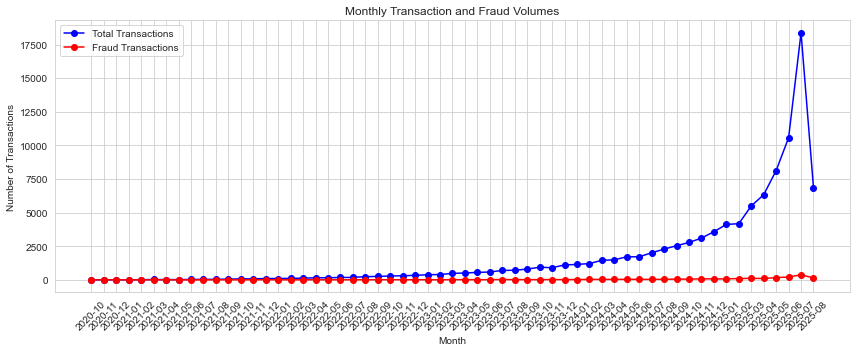

In [27]:
# Monthly transaction and fraud volume trend
df["Month"] = df["Timestamp"].dt.to_period("M")
monthly_totals = df.groupby("Month")["Transaction_ID"].count()
monthly_fraud = df.groupby("Month")["Fraud_Flag"].sum()
plt.figure(figsize=(12,5))
plt.plot(monthly_totals.index.astype(str), monthly_totals.values, marker = "o", label="Total Transactions", color = "blue")
plt.plot(monthly_fraud.index.astype(str), monthly_fraud.values, marker = "o", label="Fraud Transactions", color = "red")
plt.title("Monthly Transaction and Fraud Volumes")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.legend()
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

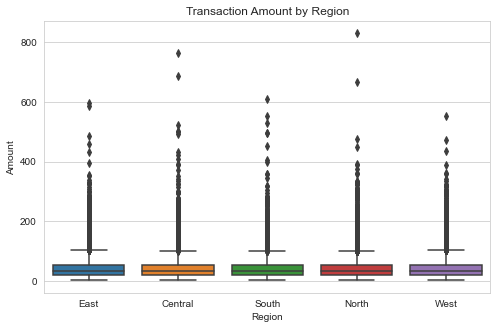

In [28]:
# Boxplot: Amount by Region
plt.figure(figsize = (8,5))
sns.boxplot(data = df, x="Region", y="Amount")
plt.title("Transaction Amount by Region")
plt.show()

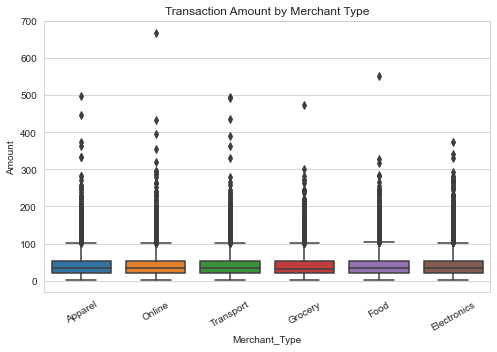

In [29]:
# Boxplot: Amount by Merchant Type
plt.figure(figsize=(8,5))
sns.boxplot(data = df, x="Merchant_Type", y = "Amount")
plt.title("Transaction Amount by Merchant Type")
plt.xticks(rotation = 30)
plt.show()

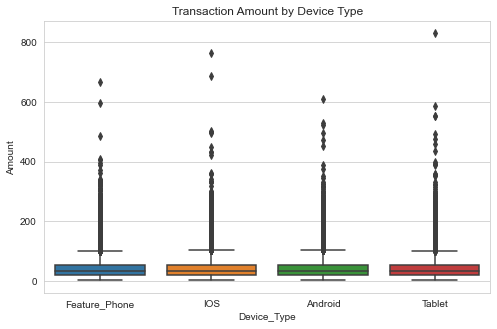

In [30]:
# Boxplot: Amount by Device Type
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Device_Type", y="Amount")
plt.title("Transaction Amount by Device Type")
plt.show()

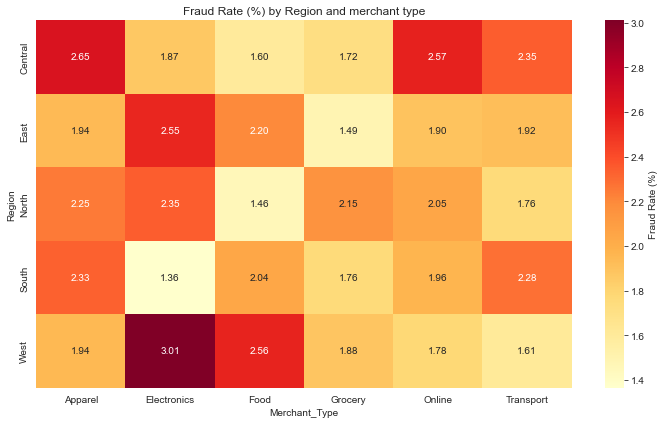

In [31]:
# Heatmap: Fraud rate % by Region vs merchant type
fraud_rate_table=df.pivot_table(index = "Region", columns = "Merchant_Type", values = "Fraud_Flag", aggfunc="mean")* 100
plt.figure(figsize=(10,6))
sns.heatmap(fraud_rate_table, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={"label": "Fraud Rate (%)"})
plt.title("Fraud Rate (%) by Region and merchant type")
plt.tight_layout()
plt.show()

In [32]:
# Grouped statistics: mean, median, standard deviation of Amount for each category
for column in ["Region", "Merchant_Type", "Device_Type"]:
    print(f"===Grouped stats for {column}===")
    stats_table = df.groupby(column)["Amount"].agg(["mean","median","std"]).round(2)
    print(stats_table)
    print()

===Grouped stats for Region===
          mean  median    std
Region                       
Central  42.49   33.34  34.54
East     42.53   32.91  34.31
North    42.21   33.07  34.18
South    42.54   33.14  34.24
West     42.33   33.05  33.67

===Grouped stats for Merchant_Type===
                mean  median    std
Merchant_Type                      
Apparel        42.10   32.82  33.77
Electronics    42.66   33.12  34.32
Food           42.39   33.46  33.13
Grocery        41.75   32.54  32.78
Online         42.99   33.22  35.58
Transport      42.89   33.40  35.75

===Grouped stats for Device_Type===
                mean  median    std
Device_Type                        
Android        42.38   33.03  34.04
Feature_Phone  42.22   32.82  33.98
IOS            42.54   33.09  34.50
Tablet         42.55   33.42  34.23



In [33]:
# High-activity and high-risk segments
for column in ["Region", "Merchant_Type", "Device_Type"]:
    total_transactions_col = df.groupby(column)["Transaction_ID"].count()
    total_fraud_col = df.groupby(column)["Fraud_Flag"].sum()
    fraud_rate_col = (total_fraud_col / total_transactions_col * 100).round(2)
    segment_summary = pd.DataFrame({
        "Total_Transactions": total_transactions_col,
        "Total_Fraud": total_fraud_col,
        "Fraud_Rate_%": fraud_rate_col})
    print(f"==== {column} Segments ====")
    print("Top High-Activity Segments (by transaction count):")
    print(segment_summary.sort_values("Total_Transactions", ascending=False))
    print()
    print("Top High-Risk Segments (by fraud rate):")
    print(segment_summary.sort_values("Fraud_Rate_%", ascending=False))
    print()

==== Region Segments ====
Top High-Activity Segments (by transaction count):
         Total_Transactions  Total_Fraud  Fraud_Rate_%
Region                                                
North                 20787          404          1.94
West                  20086          419          2.09
East                  20078          402          2.00
Central               19677          382          1.94
South                 19372          393          2.03

Top High-Risk Segments (by fraud rate):
         Total_Transactions  Total_Fraud  Fraud_Rate_%
Region                                                
West                  20086          419          2.09
South                 19372          393          2.03
East                  20078          402          2.00
Central               19677          382          1.94
North                 20787          404          1.94

==== Merchant_Type Segments ====
Top High-Activity Segments (by transaction count):
               Total_Transa

# Step 7: Statistical Analysis in Python

In [34]:
# 1. T-Test: Compare transaction amounts for Fraud vs Non-Fraud transactions
# H0: Mean amount is the same for fraud and non-fraud transactions
# H1: Mean amount is different for fraud and non-fraud transactions
amount_normal = df_transaction[df_transaction["Fraud_Flag"] == 0]["Amount"]
amount_fraud = df_transaction[df_transaction["Fraud_Flag"] == 1]["Amount"]
t_stat, p_value_ttest = stats.ttest_ind(amount_normal, amount_fraud, equal_var=False)
print("1. Two-Sample T-Test")
print("Normal group size:", len(amount_normal), "| Fraud group size:", len(amount_fraud))
print("T-statistic:", round(t_stat, 4))
print("P-value:", p_value_ttest)
 
if p_value_ttest < 0.05:
    print("Conclusion: Reject H0 -> Mean amounts are significantly different between fraud and non-fraud transactions.")
else:
    print("Conclusion: Fail to reject H0 -> No significant difference in mean amounts.")

1. Two-Sample T-Test
Normal group size: 98000 | Fraud group size: 2000
T-statistic: 0.0841
P-value: 0.9329857159373142
Conclusion: Fail to reject H0 -> No significant difference in mean amounts.


In [38]:
# 2. ANOVA: Compare transaction amounts across Merchant Types
# H0: Mean amount is the same across all merchant types
# H1: At least one merchant type has a different mean amount
merchant_type_groups = []
for merchant_type in df["Merchant_Type"].dropna().unique():
    group_data = df[df["Merchant_Type"] == merchant_type]["Amount"]
    merchant_type_groups.append(group_data)
f_stat, p_value_anova = scipy_stats.f_oneway(*merchant_type_groups)
print("2. One-Way ANOVA")
print("F-statistic:", round(f_stat, 4))
print("P-value:", p_value_anova)
if p_value_anova < 0.05:
    print("Conclusion: Reject H0 -> Mean amount is significantly different across merchant types.")
else:
    print("Conclusion: Fail to reject H0 -> No significant difference across merchant types.")

2. One-Way ANOVA
F-statistic: 0.9392
P-value: 0.4541328025189961
Conclusion: Fail to reject H0 -> No significant difference across merchant types.


In [39]:
# 3. Chi-Square Test: Association between Fraud Flag and Device Type
# H0: Fraud Flag and Device Type are independent (no relationship)
# H1: Fraud Flag and Device Type are related

contingency_table = pd.crosstab(df_transaction["Fraud_Flag"], df_transaction["Device_Type"])
chi2_stat, p_value_chi2, dof, expected = scipy_stats.chi2_contingency(contingency_table)

print("3. Chi-Square Test of Independence")
print("Chi2 Statistic:", round(chi2_stat, 4))
print("P-value:", p_value_chi2)
print("Degrees of Freedom:", dof)

if p_value_chi2 < 0.05:
    print("Conclusion: Reject H0 -> Fraud Flag and Device Type are related.")
else:
    print("Conclusion: Fail to reject H0 -> No significant relationship detected.")

3. Chi-Square Test of Independence
Chi2 Statistic: 5.6743
P-value: 0.12857773227507677
Degrees of Freedom: 3
Conclusion: Fail to reject H0 -> No significant relationship detected.


In [40]:
# 4. Correlation: Risk Score vs Fraud Occurrence

correlation_value, p_value_corr = scipy_stats.pearsonr(df["Risk_Score"], df["Fraud_Flag"])

print("4. Correlation Analysis (Pearson)")
print("Correlation value:", round(correlation_value, 4))
print("P-value:", p_value_corr)

if abs(correlation_value) < 0.1:
    print("Conclusion: Correlation is very close to zero -> No strong relationship between risk score and fraud.")
else:
    print("Conclusion: There is a noticeable relationship between risk score and fraud.")

4. Correlation Analysis (Pearson)
Correlation value: -0.0016
P-value: 0.6123161596414091
Conclusion: Correlation is very close to zero -> No strong relationship between risk score and fraud.


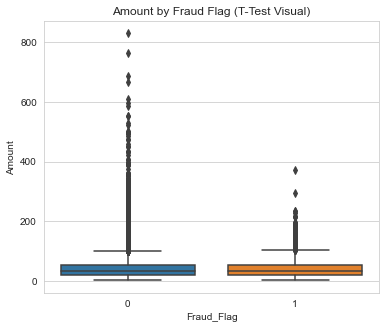

In [41]:
# Visualization 1: T-Test - Amount by Fraud Flag
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="Fraud_Flag", y="Amount")
plt.title("Amount by Fraud Flag (T-Test Visual)")
plt.show()

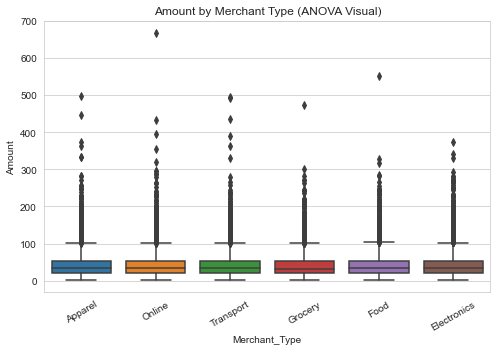

In [43]:
# Visualization 2: ANOVA - Amount by Merchant Type
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Merchant_Type", y="Amount")
plt.title("Amount by Merchant Type (ANOVA Visual)")
plt.xticks(rotation=30)
plt.show()

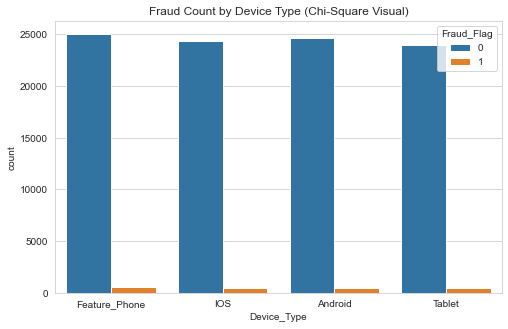

In [44]:
# Visualization 3: Chi-Square - Fraud Count by Device Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Device_Type", hue="Fraud_Flag")
plt.title("Fraud Count by Device Type (Chi-Square Visual)")
plt.show()

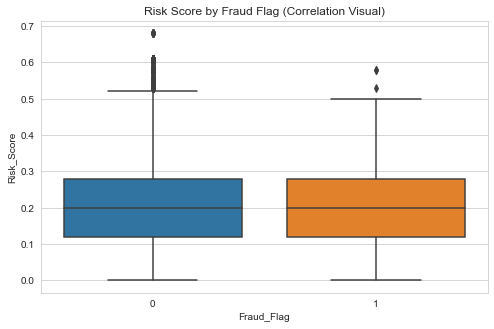

In [45]:
# Visualization 4: Correlation - Risk Score vs Fraud Flag
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Fraud_Flag", y="Risk_Score")
plt.title("Risk Score by Fraud Flag (Correlation Visual)")
plt.show()

## Document Assumptions and Limitations of the Tests Performed

## Assumptions of the Tests

In [46]:
print("T-Test: We assumed each transaction is independent, and that transaction")
print("amounts are roughly normal (or the sample size is large enough).")
print("We used Welch\'s t-test, so we did not assume equal variance between groups.")
print()
print("ANOVA: We assumed observations within each merchant type group are")
print("independent, amounts are roughly normal within each group, and variance")
print("is similar across groups.")
print()
print("Chi-Square Test: We assumed each transaction is independent, and that")
print("each cell in the contingency table has an expected count of at least 5.")
print()
print("Correlation: Pearson correlation assumes a linear relationship. Since")
print("Fraud_Flag is binary (0 or 1), this is equivalent to a point-biserial")
print("correlation.")

T-Test: We assumed each transaction is independent, and that transaction
amounts are roughly normal (or the sample size is large enough).
We used Welch's t-test, so we did not assume equal variance between groups.

ANOVA: We assumed observations within each merchant type group are
independent, amounts are roughly normal within each group, and variance
is similar across groups.

Chi-Square Test: We assumed each transaction is independent, and that
each cell in the contingency table has an expected count of at least 5.

Correlation: Pearson correlation assumes a linear relationship. Since
Fraud_Flag is binary (0 or 1), this is equivalent to a point-biserial
correlation.


## Limitations of the Tests

In [47]:
print("1. We did not correct for running multiple tests (no Bonferroni or FDR")
print("   correction), which increases the overall chance of a false positive.")
print()
print("2. Correlation does not mean causation. A correlation between risk score")
print("   and fraud only shows an association, not that one causes the other.")
print()
print("3. Results only reflect this specific dataset and time period, and may")
print("   not generalize to future data.")
print()
print("4. Fraud cases are rare compared to normal transactions (class imbalance),")
print("   which can reduce statistical power and make estimates less stable.")

1. We did not correct for running multiple tests (no Bonferroni or FDR
   correction), which increases the overall chance of a false positive.

2. Correlation does not mean causation. A correlation between risk score
   and fraud only shows an association, not that one causes the other.

3. Results only reflect this specific dataset and time period, and may
   not generalize to future data.

4. Fraud cases are rare compared to normal transactions (class imbalance),
   which can reduce statistical power and make estimates less stable.
